In [1]:
import sys
from pathlib import Path


PROJECT_ROOT = Path.cwd().parents[2]
SRC_PATH = PROJECT_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

print("Added to sys.path:", SRC_PATH)

Added to sys.path: /Users/susmitasingh/Documents/GitHub/Portfolio_Risk_Monitor/src


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from features.returns import compute_log_returns
from risk.var_historical import historical_var
from risk.var_parametric import parametric_var
from features.returns import build_returns_dataframe
from portfolio.portfolio import compute_portfolio_returns
from portfolio.portfolio_stats import portfolio_mean_std


In [9]:
df = pd.read_csv("../../../data/raw/SPY.US.csv", parse_dates=["Date"], index_col="Date")

# Compute log returns
log_returns = compute_log_returns(df)

print(log_returns.head())

Date
2005-02-28   -0.006858
2005-03-01    0.005190
2005-03-02   -0.000491
2005-03-03    0.000400
2005-03-04    0.012508
Name: Close, dtype: float64


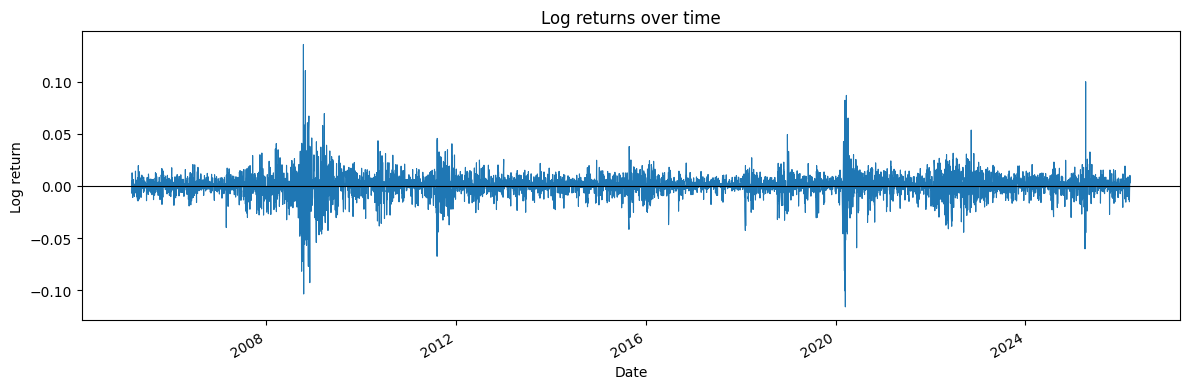

In [10]:
# Time series plot of log returns
ax = log_returns.plot(figsize=(12, 4), linewidth=0.8)
ax.set_title("Log returns over time")
ax.set_xlabel("Date")
ax.set_ylabel("Log return")
ax.axhline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()


In [11]:
var_95 = historical_var(log_returns, alpha=0.05)


In [12]:
var_95

np.float64(-0.017811393829177402)

In [6]:
# Create synthetic price data (3 assets)
dates = pd.date_range("2026-01-01", periods=6)

df1 = pd.DataFrame({
    "Close": [100, 102, 101, 103, 104, 105]
}, index=dates)

df2 = pd.DataFrame({
    "Close": [200, 198, 202, 204, 203, 205]
}, index=dates)

df3 = pd.DataFrame({
    "Close": [300, 303, 306, 309, 312, 315]
}, index=dates)

price_data = {"A": df1, "B": df2, "C": df3}

weights = [0.5, 0.3, 0.2]

In [7]:
 df_returns = build_returns_dataframe(price_data)

In [8]:
df_returns

,A,B,C
2026-01-02,0.019803,-0.010050,0.009950
2026-01-03,-0.009852,0.020001,0.009852
2026-01-04,0.019608,0.009852,0.009756
2026-01-05,0.009662,-0.004914,0.009662
2026-01-06,0.009569,0.009804,0.009569


In [9]:
port_returns = compute_portfolio_returns(df_returns, weights)
port_returns 


2026-01-02    0.008876
2026-01-03    0.003045
2026-01-04    0.014711
2026-01-05    0.005289
2026-01-06    0.009640
Freq: D, dtype: float64

In [12]:
var_hist = historical_var(port_returns, alpha=0.05)

In [13]:
var_hist

np.float64(0.0034934355027753114)

In [14]:
mu, sigma = portfolio_mean_std(df_returns, weights)

In [16]:
var_param = parametric_var(mu, sigma, alpha=0.05)

In [17]:
var_param

np.float64(0.0009600836426703532)

In [22]:
returns = pd.DataFrame({
    "A": np.random.normal(0, 0.02, 10000),
    "B": np.random.normal(0, 0.02, 10000)
})

weights = [0.5, 0.5]

In [23]:
port_returns = compute_portfolio_returns(returns, weights)
mu, sigma = portfolio_mean_std(returns, weights)

var_hist = historical_var(port_returns, alpha=0.05)
var_param = parametric_var(mu, sigma, alpha=0.05)

In [24]:
var_hist, var_param

(np.float64(-0.023419546872733756), np.float64(-0.02322104924907974))

In [25]:
var_hist-var_param

np.float64(-0.0001984976236540162)

In [26]:
1e-3

0.001

In [4]:
from scipy.stats import norm

In [10]:
norm.ppf(0.2)

np.float64(-0.8416212335729142)

In [11]:
norm.ppf(0.05)

np.float64(-1.6448536269514729)

In [3]:
csv_path = PROJECT_ROOT / "data" / "raw" / "SPY.US.csv"

In [4]:
with open(csv_path) as f:
    lines = f.readlines()
    counts = [line.count(',') for line in lines]
    print(set(counts))

{5}


In [5]:
ASSETS =  [
    "SPY.US", "QQQ.US", "IWM.US", "XLF.US",
    "XLK.US", "XLE.US", "TLT.US", "LQD.US",
    "GLD.US", "SLV.US", "VNQ.US", "XOM.US"
    ]  

In [6]:
for a in ASSETS:
    csv_path = PROJECT_ROOT / "data" / "raw" / f"{a}.csv"
    with open(csv_path) as f:
        lines = f.readlines()
        counts = [line.count(',') for line in lines]
        print(f"{a}: {set(counts)}")

SPY.US: {5}
QQQ.US: {5}
IWM.US: {5}
XLF.US: {5}
XLK.US: {5}
XLE.US: {5}
TLT.US: {5}
LQD.US: {5}
GLD.US: {5}
SLV.US: {5}
VNQ.US: {5}
XOM.US: {5}


In [ ]:
import requests

symbol = "SPY.US"
url = "https://stooq.com/q/d/l/?s=spy.us&i=d"

r = requests.get(url)
print(r.status_code)
print(repr(r.text[:1000]))  # raw chars, shows \n \r etc

200
'Get your apikey:\n\n1. Open https://stooq.com/q/d/?s=spy.us&get_apikey\n2. Enter the captcha code.\n3. Copy the CSV download link at the bottom of the page - it will contain the <apikey> variable.\n4. Append the <apikey> variable with its value to your requests, e.g.\n   https://stooq.com/q/d/l/?s=spy.us&i=d&apikey=XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX\n'


In [18]:
url = f"https://stooq.com/q/d/l/?s={symbol}&i=d"
df = pd.read_csv(url, on_bad_lines='skip')

In [21]:
df

,Get your apikey:
0,1. Open https://stooq.com/q/d/?s=SPY.US&get_ap...
1,2. Enter the captcha code.
2,3. Copy the CSV download link at the bottom of...
3,https://stooq.com/q/d/l/?s=SPY.US&i=d&apike...


In [15]:
import yfinance as yf

def fetch_stooq(symbol):
    # Stooq uses "SPY.US" format, yfinance just needs "SPY"
    ticker = symbol.split(".")[0]
    df = yf.download(ticker, period="5d", auto_adjust=True, progress=False)
    df = df.reset_index()
    df.columns = ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']  # match your existing schema
    return df


In [16]:
df_yf = fetch_stooq("QQQ.US")

In [17]:
df_yf

,Date,Open,High,Low,Close,Volume
0,2026-04-08,606.090027,609.900024,602.119995,608.710022,63086000
1,2026-04-09,610.190002,610.500000,603.030029,605.929993,37837500
2,2026-04-10,611.070007,613.669983,609.580017,611.840027,34038500
3,2026-04-13,617.390015,626.739990,608.109985,609.479980,32781900
4,2026-04-14,626.559998,627.700012,620.099976,620.270020,36607377
